In [1]:
import os
import sys
sys.path.append('/host/d/Github')  ### remove this if not needed!
import numpy as np
import pandas as pd 
from tqdm import tqdm 
from pathlib import Path
import nibabel as nb
import matplotlib.pyplot as plt

import argparse
from einops import rearrange 
from natsort import natsorted
from madgrad import MADGRAD

import torch
import torch.backends.cudnn as cudnn

from SAM_echo_xjtlu.utils.model_util import *
from SAM_echo_xjtlu.segment_anything.model import build_model 
from SAM_echo_xjtlu.utils.save_utils import *
from SAM_echo_xjtlu.utils.config_util import Config
from SAM_echo_xjtlu.utils.misc import NativeScalerWithGradNormCount as NativeScaler

from SAM_echo_xjtlu.train_engine import train_loop

import SAM_echo_xjtlu.functions_collection as ff
import SAM_echo_xjtlu.Data_processing as Data_processing
import SAM_echo_xjtlu.Build_lists.Build_list_WHS as Build_list
import SAM_echo_xjtlu.data_loader_WHS.random_aug as random_aug
import SAM_echo_xjtlu.data_loader_WHS.generator as generator
from torch.utils.data import Dataset, DataLoader


main_path = '/host/d/projects/FETUS_competition/' ### change to your main path


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15]


### step 1: define trial name

In [2]:
trial_name = 'trial_sam_WHS'
output_dir = os.path.join(main_path, 'models', trial_name) # change to your output dir
ff.make_folder([output_dir])

### step 2: define parameters for this trial

In [3]:
# many important parameters, focus on ones that I comment with ###!!

def get_args_parser(img_size = 128, num_classes = 3, pretrained_model = None, original_sam = None, start_epoch = None, total_training_epochs = 1000, save_model_every = 1,  vit_type = "vit_h"):
    parser = argparse.ArgumentParser('SAM fine-tuning', add_help=True)

    # img size
    parser.add_argument('--img_size', default=img_size, type=int)  ## !!

    ## augmentation
    parser.add_argument('--augment_frequency', default= 0.5, type=float) ## !! ise a proper frequency

    ## segmentation classes
    parser.add_argument('--num_classes', type=int, default=num_classes) ## !!

    ## pretrained sam
    parser.add_argument('--resume', default = original_sam) ##!!

    # for training
    parser.add_argument('--total_training_epochs', default = total_training_epochs, type=int)
    parser.add_argument('--accum_iter', default=20, type=int, help='Accumulate gradient iterations (for increasing the effective batch size under memory constraints)') ##!!
    parser.add_argument('--print_freq', default=10, type = int) 
    parser.add_argument('--save_model_file_every_N_epoch', default=save_model_every, type = int)  ## !!
    parser.add_argument('--batch_size', default=1, type=int, help='Batch size per GPU (effective batch size is batch_size * accum_iter * # gpus')  ## !!
    parser.add_argument('--weight_decay', type=float, default=0.05, help='weight decay (default: 0.05)')
    parser.add_argument('--lr', type=float, default=1e-4, metavar='LR', help='base learning rate: absolute_lr = base_lr * total_batch_size / 256') ## !!
    parser.add_argument('--lr_update_every_N_epoch', default=100, type = int) ## !!
    parser.add_argument('--lr_decay_gamma', default=0.95)
    parser.add_argument('--warmup_epochs', type=int, default=10, metavar='N', help='epochs to warmup LR')
    parser.add_argument('--loss_weights', default = [1,1] )  #### !! weighting for loss function [BCE, Dice]

    if start_epoch == None:
        parser.add_argument('--start_epoch', default=1, type=int, metavar='N', help='start epoch')
    else:
        parser.add_argument('--start_epoch', default= start_epoch, type=int, metavar='N', help='start epoch')

    # standard
    parser.add_argument('--text_prompt', default = False)
    parser.add_argument('--box_prompt', default= False) 
    parser.add_argument('--pretrained_model', default = pretrained_model)
    
    parser.add_argument('--validation', default=False) ## !!
    parser.add_argument('--cross_frame_attention', default=False) # False

    parser.add_argument('--model_type', type=str, default='sam')
    parser.add_argument('--n_gpu', type=int, default=1, help='total gpu') 
    parser.add_argument('--use_amp', action='store_true', help='If activated, adopt mixed precision for acceleration')
    parser.add_argument("--config", help="Path to the training config file.", default="configs/config.yaml",)

    parser.add_argument('--seed', default=1234, type=int)   
    parser.add_argument('--input_type', type=str, default='2DT') #has to be 2DT
    parser.add_argument('--vit_type', type=str, default=vit_type)
    parser.add_argument('--max_timeframe', default=5, type=int) 
                        

    parser.add_argument('--turn_zero_seg_slice_into', default=10, type=int)
 
    return parser


In [4]:
pretrained_model = None#os.path.join(output_dir, 'model-1000.pth')
start_epoch = 1 # 1 if no pretrained model
total_training_epochs = 5000 # change to a reasonable number

# define the original sam model weights (you should download it from online to your local path)
original_sam = '/host/d/Data/pretrained_SAM_weights/sam_vit_h.pth'  # change to your original sam model path

args = get_args_parser(img_size = 128, ## important !! need to change based on your dataset
        num_classes = 8, ## important !! need to change based on your dataset
        pretrained_model = pretrained_model, 
        original_sam = original_sam, 
        start_epoch = start_epoch, 
        total_training_epochs = total_training_epochs, 
        save_model_every = 50,
        vit_type = "vit_h")

args = args.parse_args([])

# some other settings
cfg = Config(args.config)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
cudnn.benchmark = True

### step 2: build patient list

In [5]:
# # change the excel path to your own path
# patient_list_spreadsheet = os.path.join('/host/d/Github/SAM_echo_xjtlu/example_data/data/Patient_list','patient_list.xlsx')
# build_sheet =  Build_list.Build(patient_list_spreadsheet)
# # train
# _, patient_id_list_train, img_file_list_train, seg_file_list_train = build_sheet.__build__(index_list=[0])  
# print('all train img files:', img_file_list_train)

# # # define val
# # _,_,input_file_val, reference_file_val = build_sheet.__build__(batch_list = [1])  # just as an example, use the same batch for val

# change the excel path to your own path
patient_list_spreadsheet = os.path.join('/host/d/Github/SAM_echo_xjtlu/example_data/data/Patient_list/train_val_path_list.xlsx')
build_sheet =  Build_list.Build(patient_list_spreadsheet)
# train
batch_list, modality_list, center_list, patient_id_list, size_x_list, size_y_list, size_z_list, img_file_list_train, seg_file_list_train = build_sheet.__build__(batch_list = [0])  # just as an example, use batch 0 for train

# # define val
# _,_,input_file_val, reference_file_val = build_sheet.__build__(batch_list = [1])  # just as an example, use the same batch for val
print('give me an example of image file and seg file:', img_file_list_train[0], seg_file_list_train[0])
print('total number of training cases:', len(img_file_list_train))



give me an example of image file and seg file: /host/d/Data/WHS/current_challenge/original_data/CT/centerA/1003/image.nii.gz /host/d/Data/WHS/current_challenge/original_data/CT/centerA/1003/label.nii.gz
total number of training cases: 1


### step 3: define data generator

In [10]:
# define this generator
# generator_train = generator.Dataset_CMR( 
#     image_file_list = img_file_list_train,
    
#     seg_file_list = seg_file_list_train,

#     image_shape = [args.img_size, args.img_size],
#     center_crop_according_to_which_class  = [1], #default: crop according to class 1 (LV)

#     shuffle = True,
#     image_normalization = True,
#     augment = True,
#     augment_frequency = args.augment_frequency,
#     )

generator_train = generator.Dataset_CMR(
            image_file_list = img_file_list_train,
            seg_file_list = seg_file_list_train,
            slice_num = 5,
            slice_range = [100,105],

            shuffle = True,
            image_normalization = True,
            augment = True,
            augment_frequency = 0,
            args = args,
    )

loading image file: /host/d/Data/WHS/current_challenge/original_data/CT/centerA/1003/image.nii.gz  seg file: /host/d/Data/WHS/current_challenge/original_data/CT/centerA/1003/label.nii.gz
after augmentation, image min: 0.0  max: 1.0
processed image shape: torch.Size([1, 1, 128, 128, 5])


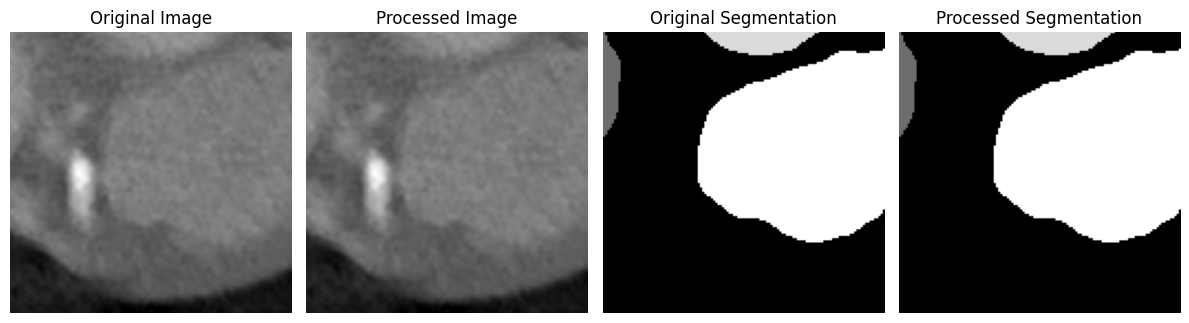

In [7]:
# let's try our dataload to see how the data augmentation looks like
## important!! after you run this, you need to re-run the above cell that defines the generator_train again, and proceed to step 4, please remember!!

# if you see error "local variable 'image_loaded' referenced before assignment", 
# to solve, please restart the jupyter notebook and run again --> actually you can just ignore the error and keep running, it won't affect anything
dl = DataLoader(generator_train, batch_size = 1, shuffle = False, pin_memory = True, num_workers = 0)# cpu_count())
for batch_idx, batch_data in enumerate(dl):
    original_img = batch_data["original_image"]
    original_seg = batch_data["original_seg"]
    processed_img = batch_data["image"]
    processed_seg = batch_data["mask"]
    print('processed image shape:', processed_img.shape)
   
    # plot 4 images side by side --> you should see the data augmentation effects
    fig, axs = plt.subplots(1, 4, figsize=(12, 4))
    axs[0].imshow(original_img[0,0,:,:,0], cmap='gray')
    axs[1].imshow(processed_img[0,0,:,:,0], cmap='gray')
    axs[2].imshow(original_seg[0,0,:,:,0], cmap='gray')
    axs[3].imshow(processed_seg[0,0,:,:,0], cmap='gray')
    axs[0].set_title('Original Image')
    axs[1].set_title('Processed Image')
    axs[2].set_title('Original Segmentation')
    axs[3].set_title('Processed Segmentation')
    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    break
    

### step 4: load pre-trained SAM model (freeze SAM blocks)

In [8]:
# set model
model = build_model(args, device)

# set freezed and trainable keys
train_keys = []
freezed_keys = []
        
# load pretrained sam model vit_h
if args.model_type.startswith("sam"):
    if args.resume.endswith(".pth"):
        with open(args.resume, "rb") as f:
            state_dict = torch.load(f)
        try:
            model.load_state_dict(state_dict)
        except:
            if args.vit_type == "vit_h" or args.vit_type == "vit_l" or args.vit_type == "vit_b":
                new_state_dict = load_from(model, state_dict, args.img_size,  16, [7, 15, 23, 31])
               
            model.load_state_dict(new_state_dict)
        
        # freeze original SAM layers
        freeze_list = [ "norm1", "attn" , "mlp", "norm2"]  
                
        for n, value in model.named_parameters():
            if any(substring in n for substring in freeze_list):
                freezed_keys.append(n)
                value.requires_grad = False
            else:
                train_keys.append(n)
                value.requires_grad = True

## Select optimization method
optimizer = MADGRAD(model.parameters(), lr=args.lr)
        
# Continue training model
if args.pretrained_model is not None:
    if os.path.exists(args.pretrained_model):
        print('loading pretrained model : ', args.pretrained_model)
        args.resume = args.pretrained_model
        finetune_checkpoint = torch.load(args.pretrained_model)
        model.load_state_dict(finetune_checkpoint["model"])
        optimizer.load_state_dict(finetune_checkpoint["optimizer"])
        torch.cuda.empty_cache()
else:
    print('new training\n')

Important! text prompt: False
Important! box prompt: False
new training



### final step: let's train!!

In [11]:
# training loader
data_loader_train = DataLoader(generator_train, batch_size = 1, shuffle = False, pin_memory = True, num_workers = 0)# cpu_count())

training_log = []
model_save_folder = os.path.join(output_dir, 'models'); ff.make_folder([output_dir, model_save_folder])
log_save_folder = os.path.join(output_dir, 'logs'); ff.make_folder([log_save_folder])

for epoch in range(args.start_epoch,  args.total_training_epochs+1):
        print('training epoch:', epoch)

        if epoch % args.lr_update_every_N_epoch == 0:
            optimizer.param_groups[0]["lr"] = optimizer.param_groups[0]["lr"] * args.lr_decay_gamma
        # print('learning rate now:', optimizer.param_groups[0]["lr"])
        
        loss_scaler = NativeScaler()
            
        train_results = train_loop(
                model = model,
                data_loader_train  = data_loader_train,
                optimizer = optimizer,
                epoch = epoch, 
                loss_scaler = loss_scaler,
                args = args,
                inputtype = cfg.data.input_type)   
              
        loss, lossCE, lossDICE = train_results
        print('in epoch: ', epoch, ' training average_loss: ', loss, ' average_lossCE: ', lossCE, ' average_lossDICE: ', lossDICE,)
    
        # on_epoch_end:
        generator_train.on_epoch_end()
    
        if  epoch % args.save_model_file_every_N_epoch == 0 or epoch  == args.total_training_epochs:
            checkpoint_path = os.path.join(model_save_folder,  'model-%s.pth' % epoch)
            to_save = {
                        'model': model.state_dict(),
                        'optimizer': optimizer.state_dict(),
                        'epoch': epoch,
                        'scaler': loss_scaler.state_dict(),
                        'args': args,}
            torch.save(to_save, checkpoint_path)

        training_log.append([epoch, optimizer.param_groups[0]["lr"], loss, lossCE, lossDICE])
        df = pd.DataFrame(training_log, columns=['epoch', 'lr','training_loss', 'training_lossCE', 'training_lossDICE'])
        df.to_excel(os.path.join(log_save_folder, 'training_log.xlsx'), index=False)

training epoch: 1


  0%|          | 0/1 [00:00<?, ?it/s]

loading image file: /host/d/Data/WHS/current_challenge/original_data/CT/centerA/1003/image.nii.gz  seg file: /host/d/Data/WHS/current_challenge/original_data/CT/centerA/1003/label.nii.gz
after augmentation, image min: 0.0  max: 1.0


100%|██████████| 1/1 [00:14<00:00, 14.66s/it]


in epoch:  1  training average_loss:  27.538808822631836  average_lossCE:  26.5634708404541  average_lossDICE:  0.9753381609916687
now run on_epoch_end function
training epoch: 2


...

after augmentation, image min: 0.0  max: 1.0
in epoch:  2  training average_loss:  4.911496639251709  average_lossCE:  3.9157423973083496  average_lossDICE:  0.9957544207572937
now run on_epoch_end function
training epoch: 3


  0%|          | 0/1 [00:00<?, ?it/s]

loading image file: /host/d/Data/WHS/current_challenge/original_data/CT/centerA/1003/image.nii.gz  seg file: /host/d/Data/WHS/current_challenge/original_data/CT/centerA/1003/label.nii.gz


  0%|          | 0/1 [00:02<?, ?it/s]


KeyboardInterrupt: 